<a href="https://colab.research.google.com/github/An1ru5h/nike-financial-analysis/blob/main/Nike_financials.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sklearn as sk

In [4]:
#Load Data
df=pd.read_csv("/content/sample_data/nike_financials.csv")
df

,year,revenue,cost_of_sales,gross_profit,sga_expenses,net_income,total_assets,total_liabilities,total_equity
0,2023,51217,28925,22292,16377,5070,37531,23527,14004
1,2024,51362,28475,22887,16576,5700,38110,23680,14430
2,2025,46309,26519,19790,16088,3219,36579,23366,13213


In [5]:
df['gross_margin']=df['gross_profit']/df['revenue'] # Calculate gross margin
df['net_margin']=df['net_income']/df['revenue']     # Calculate net margin
df['revenue_growth']= df["revenue"].pct_change()    # Calculate revenue growth percentage change year-over-year
df["debt_to_equity"] = df["total_liabilities"] / df["total_equity"] # Calculate debt-to-equity ratio
df["return_on_assets"] = df["net_income"] / df["total_assets"] # Calculate return on assets

# Format percentages for display purposes
display = df.copy() # Create a copy of the DataFrame for formatting to avoid modifying the original 'df'

# Iterate through selected columns to apply specific formatting
for col in ["gross_margin", "net_margin", "revenue_growth",
            "debt_to_equity", "return_on_assets"]:
    if col == "debt_to_equity":
        display[col] = display[col].round(2) # Round debt_to_equity to two decimal places
    else:
        # For other columns, convert to percentage, round, and append '%' sign
        display[col] = (display[col] * 100).round(2).astype(str) + "%"

# Replace 'nan%' strings with 'N/A' in the 'revenue_growth' column for better readability
display["revenue_growth"] = display["revenue_growth"].replace('nan%', 'N/A')

print(display) # Print the formatted DataFrame to standard output
display # Display the formatted DataFrame in the notebook output

   year  revenue  cost_of_sales  gross_profit  sga_expenses  net_income  \
0  2023    51217          28925         22292         16377        5070   
1  2024    51362          28475         22887         16576        5700   
2  2025    46309          26519         19790         16088        3219   

   total_assets  total_liabilities  total_equity gross_margin net_margin  \
0         37531              23527         14004       43.52%       9.9%   
1         38110              23680         14430       44.56%      11.1%   
2         36579              23366         13213       42.73%      6.95%   

  revenue_growth  debt_to_equity return_on_assets  
0            N/A            1.68           13.51%  
1          0.28%            1.64           14.96%  
2         -9.84%            1.77             8.8%  


,year,revenue,cost_of_sales,gross_profit,sga_expenses,net_income,total_assets,total_liabilities,total_equity,gross_margin,net_margin,revenue_growth,debt_to_equity,return_on_assets
0,2023,51217,28925,22292,16377,5070,37531,23527,14004,43.52%,9.9%,N/A,1.68,13.51%
1,2024,51362,28475,22887,16576,5700,38110,23680,14430,44.56%,11.1%,0.28%,1.64,14.96%
2,2025,46309,26519,19790,16088,3219,36579,23366,13213,42.73%,6.95%,-9.84%,1.77,8.8%


---
##Revenue Trend

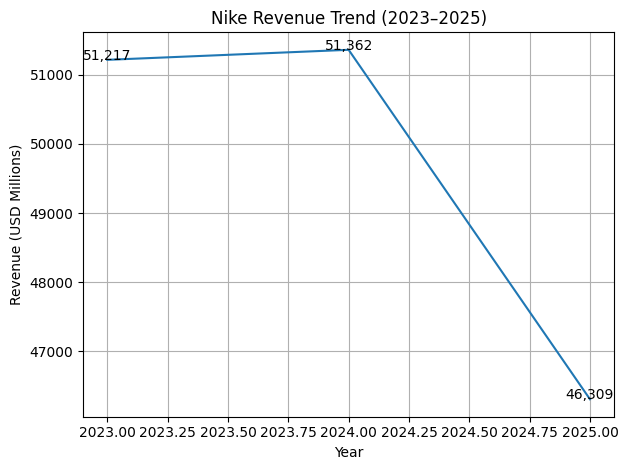

In [6]:
plt.plot(df['year'],df['revenue'])
plt.xlabel('Year')
plt.ylabel('Revenue (USD Millions)')
# Show data labels
for x, y in zip(df["year"], df["revenue"]):
    plt.text(x, y, f"{y:,}", ha="center")
plt.title('Nike Revenue Trend (2023–2025)')
plt.grid(True)
plt.tight_layout()
plt.show()

---
##Gross Profit vs Net Income

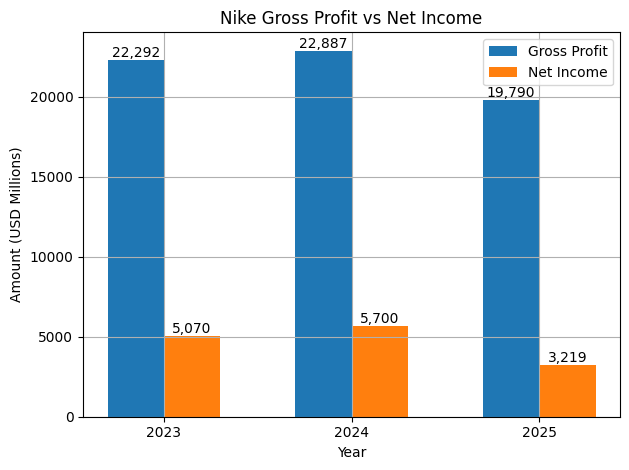

In [7]:
width = .30
x = df['year'] #Where "Year" is being assigned to the x-aixs

#Histogram
plt.bar(x - width/2, df['gross_profit'], width, label="Gross Profit") # Plots the graph on the "Left Side"
plt.bar(x + width/2, df['net_income'], width, label="Net Income") #Plots the grpah on the "Right Side"

#Data Label
for a, b in zip(x - width/2, df['gross_profit']):
    plt.text(a, b, f"{b:,}", ha="center", va="bottom")

for a, b in zip(x + width/2, df['net_income']):
    plt.text(a, b, f"{b:,}", ha="center", va="bottom")

plt.xlabel('Year')
plt.ylabel('Amount (USD Millions)')
plt.title('Nike Gross Profit vs Net Income')
plt.legend()
plt.grid(True)
plt.xticks(x)
plt.tight_layout()

---
##Gross Margin vs Net Margin

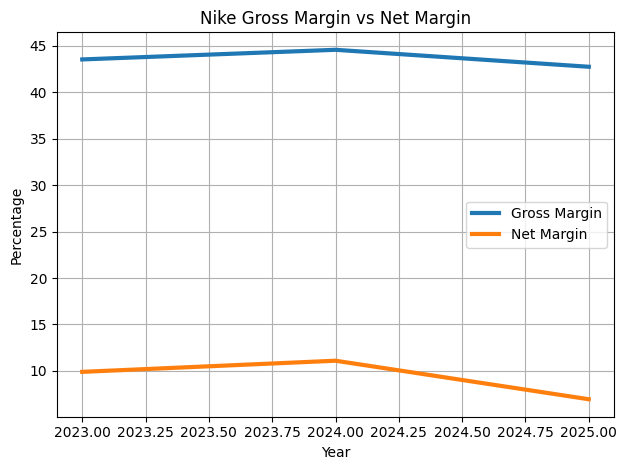

In [8]:
plt.plot(df['year'],df['gross_margin']*100, label="Gross Margin", linewidth=3)
plt.plot(df['year'],df['net_margin']*100, label="Net Margin", linewidth=3)
plt.title('Nike Gross Margin vs Net Margin')
plt.xlabel('Year')
plt.ylabel('Percentage')
plt.legend()
plt.grid(True)
plt.tight_layout()

##Forcasting

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


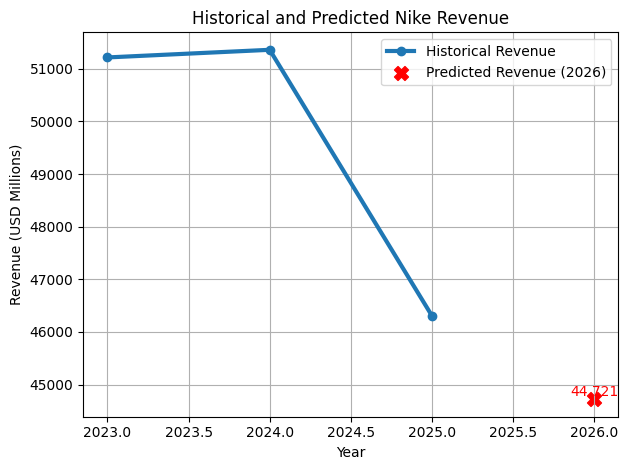

In [13]:
from sklearn.linear_model import LinearRegression

# Prepare data for the model
x = df[["year"]]
y = df[["revenue"]]

# Create and train the linear regression model
model = LinearRegression()
model.fit(x, y)

futrue_year = np.array([2026]).reshape(-1, 1) # Reshape to a 2D array
predicted_revenue = model.predict(futrue_year)

plt.plot(df["year"], df["revenue"], marker="o", linewidth=3, label="Historical Revenue")
plt.scatter(futrue_year[0][0], predicted_revenue[0][0], color='red', marker='X', s=100, label='Predicted Revenue (2026)') # Plot the predicted point
plt.text(futrue_year[0][0], predicted_revenue[0][0], f'{predicted_revenue[0][0]:,.0f}', ha='center', va='bottom', color='red')

plt.xlabel('Year')
plt.ylabel('Revenue (USD Millions)')
plt.title('Historical and Predicted Nike Revenue')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
from sklearn.linear_model import LinearRegression

x=df[["year"]]
y=df[["revenue"]]

model=LinearRegression()
model.fit(x,y)

predicted_revenue=model.predict(x)
print(f"Predicted Revenue for 2026: ${predicted_revenue[0]} million")

Predicted Revenue for 2026: $[52083.33333333] million


#Scenario Analysis.
---
## Step 1: Create Revenue Scenarios
We will use Nike's 2025 revenue as the starting point:
2025 Revenue = $46,309 million

| Scenario   |        Assumption        |
| ---------- | -----------------------: |
| Worst Case | Revenue decreases by 10% |
| Base Case  |      Revenue grows by 5% |
| Best Case  |     Revenue grows by 12% |
---

##Step 2: Calculate Forecast Revenue
Formula:
Future Revenue = Current Revenue × (1 + Growth Rate)

In [15]:
current_revenue=df.loc[df['year']==2025, 'revenue'].values[0] #Where current_revenue becomes= $46,309 million
cases=pd.DataFrame({"Scencario":["Wrost Case", "Base Case", "Best Case"], "Growth Rate":[-0.1, 0.05, 0.12]})
scenarios=cases.copy()

scenarios["Forcast Revenue"] = current_revenue * (1 + scenarios["Growth Rate"])
scenarios

,Scencario,Growth Rate,Forcast Revenue
0,Wrost Case,-0.10,41678.10
1,Base Case,0.05,48624.45
2,Best Case,0.12,51866.08


##Step 3: Forecast Gross Profit
Gross Margin = Gross Profit/Revenue

In [16]:
gross_margin=df.loc[df['year']==2025, 'gross_margin'].values[0] #Where gross_margin becomes= $19,790
scenarios["Forecast Gross Profit"]= (scenarios["Forcast Revenue"])* gross_margin
scenarios

,Scencario,Growth Rate,Forcast Revenue,Forecast Gross Profit
0,Wrost Case,-0.10,41678.10,17811.0
1,Base Case,0.05,48624.45,20779.5
2,Best Case,0.12,51866.08,22164.8


##Stpe 4: Forecast Net Income
Net Income= Net Margin/Revenue

In [18]:
net_margin = df.loc[
    df["year"] == 2025,
    "net_margin"
].values[0]


scenarios["Forecast Net Income"] = ( scenarios["Forcast Revenue"] * net_margin)

scenarios

,Scencario,Growth Rate,Forcast Revenue,Forecast Gross Profit,Forecast Net Income
0,Wrost Case,-0.10,41678.10,17811.0,2897.10
1,Base Case,0.05,48624.45,20779.5,3379.95
2,Best Case,0.12,51866.08,22164.8,3605.28


---
##Step 5: Visualize Scenario Analysis

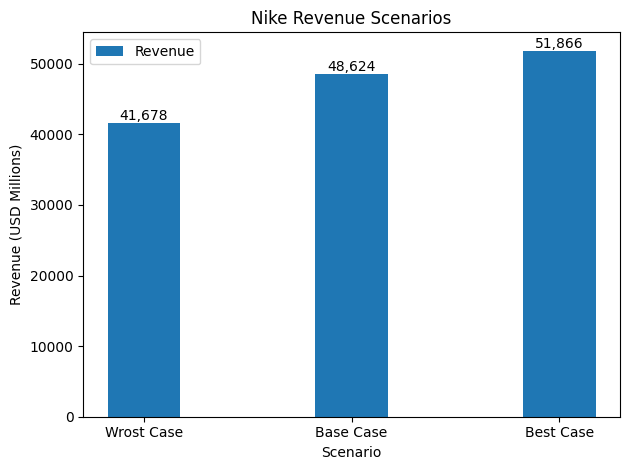

In [17]:
width=.35
plt.bar(scenarios["Scencario"], scenarios["Forcast Revenue"], width, label="Revenue")
#Data Label
for index, row in scenarios.iterrows():
    scenario = row["Scencario"]
    revenue = row["Forcast Revenue"]
    plt.text(scenario, revenue, f"{revenue:,.0f}", ha="center", va="bottom")

plt.title("Nike Revenue Scenarios")
plt.xlabel("Scenario")
plt.ylabel("Revenue (USD Millions)")
plt.legend()
plt.tight_layout()

plt.show()

##2025 Actual vs 2026 Forecast

In [25]:
# Add 'operating_income' to df DataFrame
df["operating_income"] = df["gross_profit"] - df["sga_expenses"]

actual = df[df["year"] == 2025].iloc[0]

# Extract base case forecast from scenarios DataFrame
base_case_forecast = scenarios[scenarios['Scencario'] == 'Base Case'].iloc[0]

# Calculate missing forecast metrics based on 2025 ratios
revenue_2025 = actual["revenue"]
cost_of_sales_ratio_2025 = actual["cost_of_sales"] / revenue_2025
sga_expenses_ratio_2025 = actual["sga_expenses"] / revenue_2025

# Forecast values for Base Case
forecast_revenue = base_case_forecast["Forcast Revenue"]
forecast_gross_profit = base_case_forecast["Forecast Gross Profit"]
forecast_net_income = base_case_forecast["Forecast Net Income"]

forecast_cost_of_sales = forecast_revenue * cost_of_sales_ratio_2025
forecast_sga_expenses = forecast_revenue * sga_expenses_ratio_2025
forecast_operating_income = forecast_gross_profit - forecast_sga_expenses

# Create a forecast Series for easy access
forecast_dict = {
    "Revenue": forecast_revenue,
    "Cost of Sales": forecast_cost_of_sales,
    "Gross Profit": forecast_gross_profit,
    "SG&A Expenses": forecast_sga_expenses,
    "Operating Income": forecast_operating_income,
    "Net Income": forecast_net_income
}
forecast = pd.Series(forecast_dict)

comparison = pd.DataFrame({
    "Financial Metric": [
        "Revenue",
        "Cost of Sales",
        "Gross Profit",
        "SG&A Expenses",
        "Operating Income",
        "Net Income"
    ],
    "2025 Actual": [
        actual["revenue"],
        actual["cost_of_sales"],
        actual["gross_profit"],
        actual["sga_expenses"],
        actual["operating_income"],
        actual["net_income"]
    ],
    "2026 Forecast": [
        forecast["Revenue"],
        forecast["Cost of Sales"],
        forecast["Gross Profit"],
        forecast["SG&A Expenses"],
        forecast["Operating Income"],
        forecast["Net Income"]
    ]
})

comparison["Change"] = (
    comparison["2026 Forecast"] - comparison["2025 Actual"]
)

comparison["Growth (%)"] = (
    comparison["Change"] / comparison["2025 Actual"] * 100
).round(2)

comparison = comparison.round(2)

print(comparison)

   Financial Metric  2025 Actual  2026 Forecast   Change  Growth (%)
0           Revenue      46309.0       48624.45  2315.45         5.0
1     Cost of Sales      26519.0       27844.95  1325.95         5.0
2      Gross Profit      19790.0       20779.50   989.50         5.0
3     SG&A Expenses      16088.0       16892.40   804.40         5.0
4  Operating Income       3702.0        3887.10   185.10         5.0
5        Net Income       3219.0        3379.95   160.95         5.0


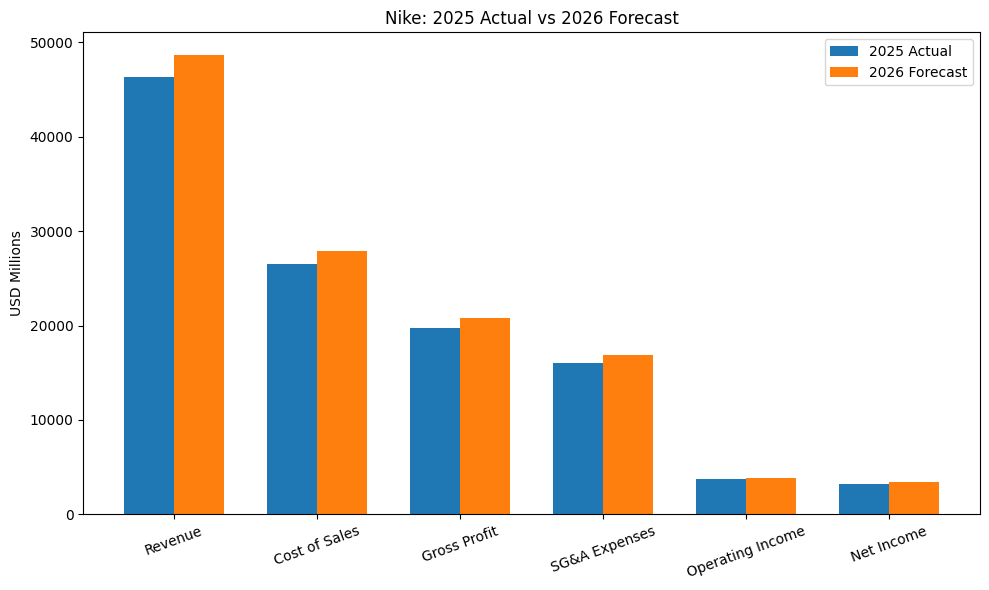

In [27]:
x = np.arange(len(comparison))
width = 0.35

plt.figure(figsize=(10,6))

plt.bar(x - width/2, comparison["2025 Actual"], width, label="2025 Actual")
plt.bar(x + width/2, comparison["2026 Forecast"], width, label="2026 Forecast")

plt.xticks(x, comparison["Financial Metric"], rotation=20)
plt.ylabel("USD Millions")
plt.title("Nike: 2025 Actual vs 2026 Forecast")
plt.legend()

plt.tight_layout()
plt.show()